### This session is designed for Python beginners. We will use a weather.csv file and build a CART classification decision tree using the built-in DecisionTreeClassifier from scikit-learn.

### Import the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


### Read the CSV file

In [2]:
df = pd.read_csv("weather.csv")

### Separating features and target

In [3]:
X_features = df.drop("Play", axis=1)
y_target = df["Play"]


Machine-learning algorithms generally need numerical representations for the features.

So we need to convert:

* Sunny
* Rain
* Overcast

into numerical columns.

We will use a built-in pandas function called: **pd.get_dummies()**

### Convert categorical data into numbers

In [4]:
X_encoded = pd.get_dummies(X_features)
X_encoded
### This process is called one-hot encoding.

,Windy,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal
0,False,0,0,1,0,1,0,1,0
1,True,0,0,1,0,1,0,1,0
2,False,1,0,0,0,1,0,1,0
3,False,0,1,0,0,0,1,1,0
4,False,0,1,0,1,0,0,0,1
5,True,0,1,0,1,0,0,0,1
6,True,1,0,0,1,0,0,0,1
7,False,0,0,1,0,0,1,1,0
8,False,0,0,1,1,0,0,0,1
9,False,0,1,0,0,0,1,0,1


What happened to Windy?
Windy contains:
* True
* False

### Create the CART model

In [5]:
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42 ## The important point is that we use a fixed value so that we can reproduce the same result.
)

### What is criterion="gini"?
CART classification trees commonly use Gini impurity to select splits.

So the model will use Gini impurity when deciding how to split the data.

### Train the CART model

In [6]:
model.fit(X_encoded, y_target)

DecisionTreeClassifier(random_state=42)

### Make our first prediction

In [7]:
new_data = pd.DataFrame([{
    "Outlook": "Sunny",
    "Temperature": "Cool",
    "Humidity": "High",
    "Windy": False
}])


### Encode the new data

Remember, our model was trained using:

X_encoded

Therefore, the new data must have the same feature columns.

In [8]:
new_data_encoded = pd.get_dummies(new_data)

new_data_encoded = new_data_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)


### Predict

In [9]:
prediction = model.predict(new_data_encoded)
print("Prediction:", prediction[0])


Prediction: No


### Visualize the CART tree

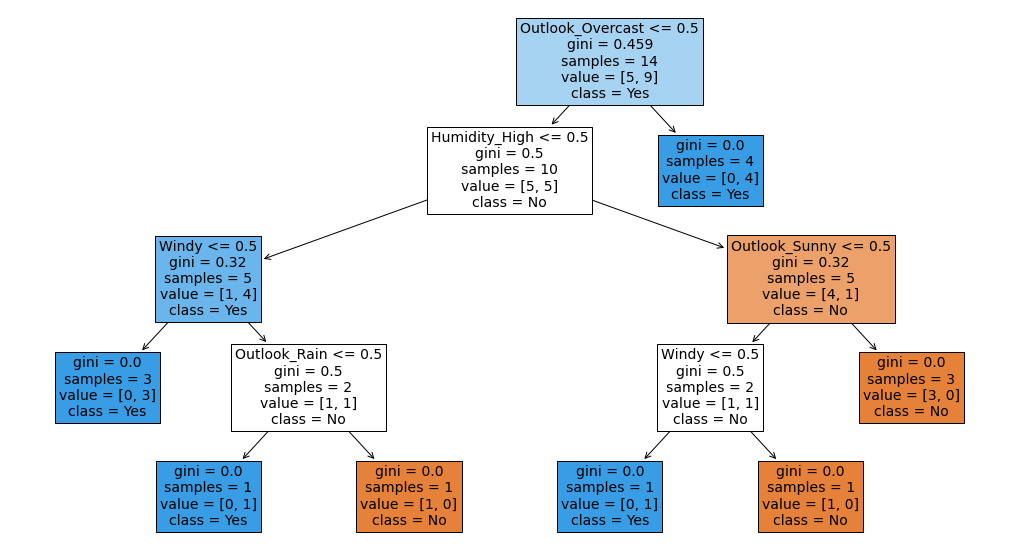

In [10]:
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=model.classes_,
    filled=True,
    fontsize=14
)

plt.show()


### A Gini value of: 0 means the node is completely pure.
### value = [5, 9]  --> [No, Yes]
* No  = 5
* Yes = 9
* class = Yes  means the node's predicted class is Yes.

### Complete Program

Dataset:
     Outlook Temperature Humidity  Windy Play
0      Sunny         Hot     High  False   No
1      Sunny         Hot     High   True   No
2   Overcast         Hot     High  False  Yes
3       Rain        Mild     High  False  Yes
4       Rain        Cool   Normal  False  Yes
5       Rain        Cool   Normal   True   No
6   Overcast        Cool   Normal   True  Yes
7      Sunny        Mild     High  False   No
8      Sunny        Cool   Normal  False  Yes
9       Rain        Mild   Normal  False  Yes
10     Sunny        Mild   Normal   True  Yes
11  Overcast        Mild     High   True  Yes
12  Overcast         Hot   Normal  False  Yes
13      Rain        Mild     High   True   No

Encoded Features:
    Windy  Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temperature_Cool  \
0   False                 0             0              1                 0   
1    True                 0             0              1                 0   
2   False                 1             0       

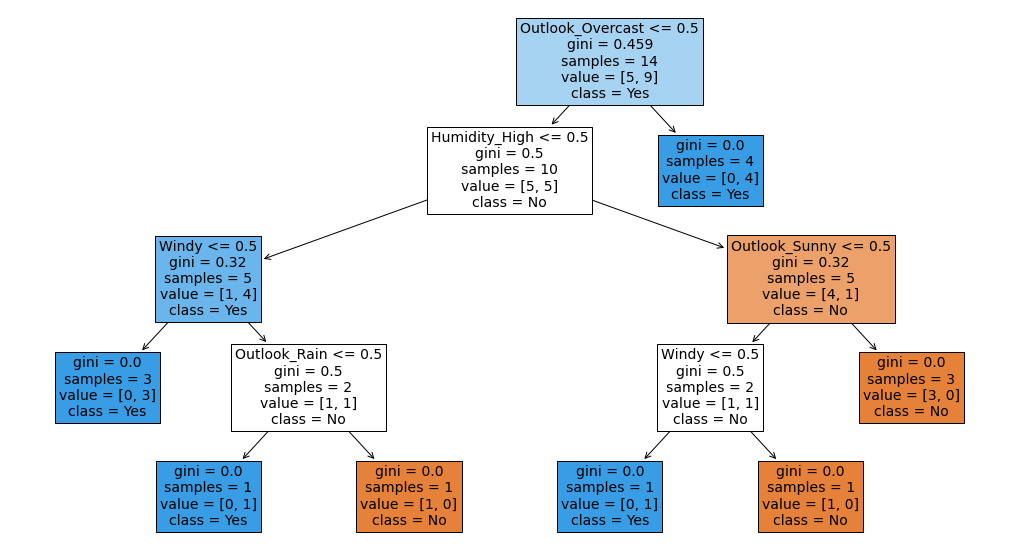

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


# 1. Load dataset
df = pd.read_csv("weather.csv")

print("Dataset:")
print(df)

# 2. Separate features and target
X = df.drop("Play", axis=1)
y = df["Play"]

# 3. Convert categorical data into numbers
X_encoded = pd.get_dummies(X)

print("\nEncoded Features:")
print(X_encoded)

# 4. Create CART decision tree
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# 5. Train the model
model.fit(X_encoded, y)

# 6. Display tree information
print("\nTree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

# 7. New data
new_data = pd.DataFrame([{
    "Outlook": "Sunny",
    "Temperature": "Cool",
    "Humidity": "High",
    "Windy": False
}])

# 8. Encode new data
new_data_encoded = pd.get_dummies(new_data)

new_data_encoded = new_data_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

# 9. Prediction
prediction = model.predict(new_data_encoded)

print("\nPrediction:", prediction[0])

# 10. Prediction probability
probability = model.predict_proba(new_data_encoded)

print("Probability:", probability)

# 11. Visualize tree
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=model.classes_,
    filled=True,
    fontsize=14
)

plt.show()
